# Exercise 2: Simulating heat diffusion on the GPU

## Tasks

We are going to solve the heat equation, which is
$
\frac{\partial u}{\partial t} = \kappa \frac{\partial^2 u}{\partial x^2}
$

We need to do the following: 
* Create variables u0 and u1. u0 are the "old" temperatures, u1 are the new temperatures.
* Initialize the original temperature
* In a for-loop, solve the heat equation one timestep at a time
* Plot after x timesteps

## Solution

The following cells include both the CPU implementation and the GPU implementation with PyCUDA from `heat_eq_1d_solution.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.autoinit

In [3]:
def heatEquation(u0, num_timesteps, kappa, dt, dx, plot_every=100):
    u1 = np.empty_like(u0)
    num_cells = u0.shape[0]

    plt.figure(figsize=(8, 5))
    plt.plot(u0, label="Initial temperature")

    for n in range(num_timesteps):

        for i in range(1, num_cells - 1):
            u1[i] = u0[i] + kappa * dt / (dx * dx) * (
                u0[i - 1] - 2 * u0[i] + u0[i + 1]
            )

        # Boundary conditions
        u1[0] = u0[0]
        u1[num_cells - 1] = u0[num_cells - 1]

        # Swap old and new temperatures
        u0, u1 = u1, u0

        if (n + 1) % plot_every == 0:
            plt.plot(u0, label=f"Step {n + 1}")

    plt.xlabel("Cell")
    plt.ylabel("Temperature")
    plt.title("1D Heat Equation")
    plt.legend()
    plt.grid()
    plt.show()

    return u0

## GPU implementation

Below is the GPU version of the 1D heat equation using PyCUDA.

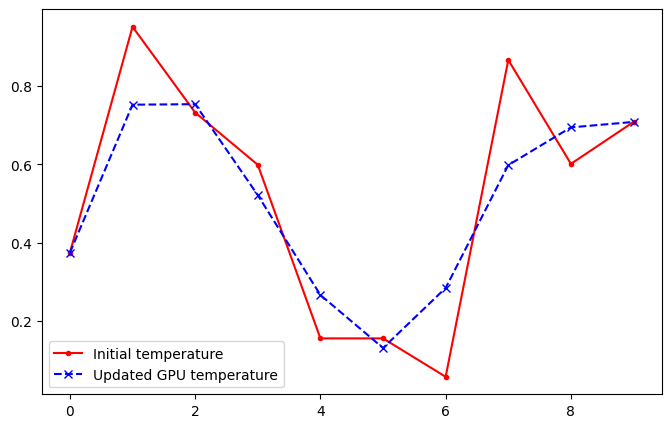

In [4]:
heat_eqn_kernel_src = """
__global__ void heatEqn1D(
            float* u1,
            float* u0,
            float kappa,
            float dx,
            float dt,
            unsigned int nx) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;

    // First cell: boundary
    if (i == 0) {
        u1[i] = u0[i];
    }
    // Last cell: boundary
    else if (i == nx-1) {
        u1[i] = u0[i];
    }
    // Internal cells
    else if (i < nx-1) {
        u1[i] = u0[i] + kappa*dt/(dx*dx) * (u0[i-1] - 2*u0[i] + u0[i+1]);
    }
}
"""

mod = SourceModule(heat_eqn_kernel_src)
heatEqnGPU = mod.get_function("heatEqn1D")


def heatEquationGPU(u0, num_timesteps, kappa, dt, dx):
    assert u0.dtype == np.float32

    u1_gpu = cuda.mem_alloc(u0.nbytes)
    u0_gpu = cuda.mem_alloc(u0.nbytes)
    cuda.memcpy_htod(u0_gpu, u0)

    num_cells = u0.shape[0]
    block = (512, 1, 1)
    grid = (int(np.ceil(num_cells / 512)), 1, 1)

    for n in range(num_timesteps):
        heatEqnGPU(
            u1_gpu,
            u0_gpu,
            np.float32(kappa),
            np.float32(dx),
            np.float32(dt),
            np.uint32(num_cells),
            block=block,
            grid=grid,
        )
        u0_gpu, u1_gpu = u1_gpu, u0_gpu

    u1 = np.empty_like(u0)
    cuda.memcpy_dtoh(u1, u0_gpu)
    return u1

np.random.seed(42)
initial_temp_gpu = np.random.rand(10).astype(np.float32)
u1_gpu = heatEquationGPU(u0=initial_temp_gpu.copy(), kappa=1, dt=0.25, dx=1, num_timesteps=1)

plt.figure(figsize=(8, 5))
plt.plot(initial_temp_gpu, 'r.-', label="Initial temperature")
plt.plot(u1_gpu, 'bx--', label="Updated GPU temperature")
plt.legend()
plt.show()

In [5]:
num_cells = 100

kappa = 1.0
dx = 1.0
dt = 0.25

num_timesteps = 500
plot_every = 100

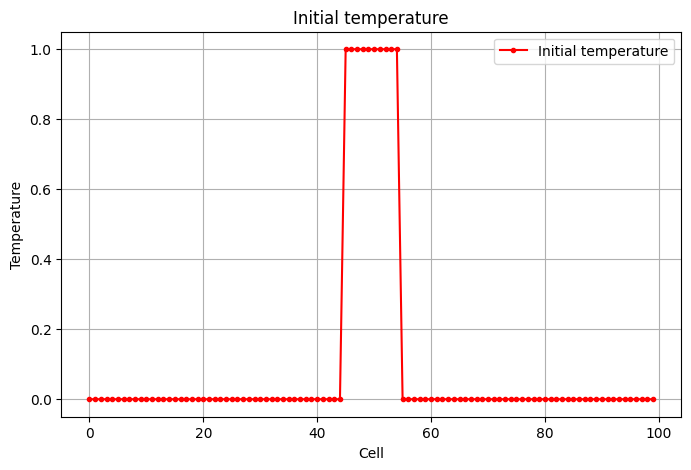

In [6]:
u0 = np.zeros(num_cells)

# Hot region in the middle
u0[45:55] = 1.0

plt.figure(figsize=(8, 5))
plt.plot(u0, "r.-", label="Initial temperature")
plt.xlabel("Cell")
plt.ylabel("Temperature")
plt.title("Initial temperature")
plt.legend()
plt.grid()
plt.show()

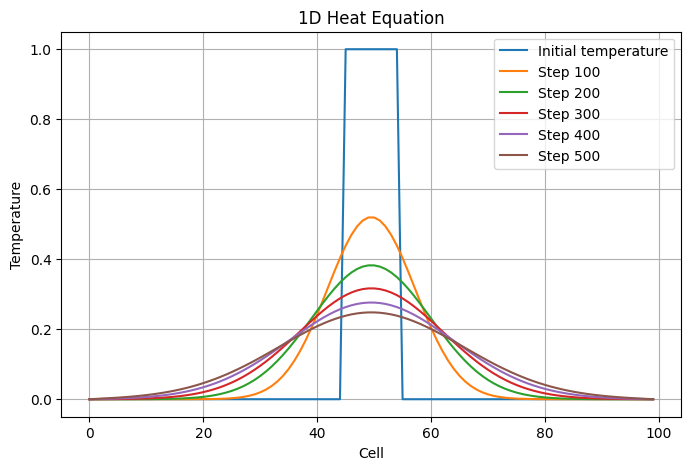

In [7]:
u_final = heatEquation(
    u0=u0.copy(),
    num_timesteps=num_timesteps,
    kappa=kappa,
    dt=dt,
    dx=dx,
    plot_every=plot_every
)

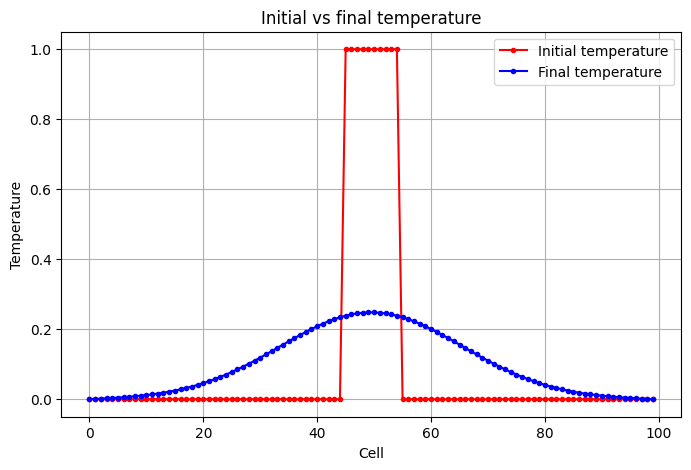

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(u0, "r.-", label="Initial temperature")
plt.plot(u_final, "b.-", label="Final temperature")
plt.xlabel("Cell")
plt.ylabel("Temperature")
plt.title("Initial vs final temperature")
plt.legend()
plt.grid()
plt.show()